# Application of Scalable Composite Transformations to Americas Subregion Data

This notebook contains code for applying the Scalable Composite Transformations model to data from the Community Earth System (CESM) large ensemble project (Kay et al., 2015) as reported in Brachem, Wiemann & Katzfuss (2026).

- Brachem, J., Wiemann, P.F.V., & Katzfuss, M. (2026) Data-Efficient Generative Modeling of Non-Gaussian Global Climate Fields via Scalable Composite Transformations.
- Kay, J. E., Deser, C., Phillips, A., Mai, A., Hannay, C., Strand, G., Arblaster, J. M., Bates, S. C., Danabasoglu, G., Edwards, J., Holland, M., Kushner, P., Lamarque, J.-F., Lawrence, D., Lindsay, K., Middleton, A., Munoz, E., Neale, R., Oleson, K., … Vertenstein, M. (2015). The Community Earth System Model (CESM) large ensemble project: A community resource for studying climate change in the presence of internal climate variability. Bulletin of the American Meteorological Society, 96(8), 1333–1349. https://doi.org/10.1175/BAMS-D-13-00255.1

## Required Software

This project requires Python 3.13.

The library `ppptm` can be installed via 

```
pip install git+https://github.com/jobrachem/ppptm.git
```

For running the Jupyter notebook, you may need to also install `ipykernel` and/or `jupyter`:

```
pip install ipykernel jupyter
```

## Setup

In [76]:
%matplotlib inline

### Library imports

In [77]:
import time
from dataclasses import dataclass
from typing import Literal

import jax
import jax.numpy as jnp
import liesel.goose as gs
import numpy as np
import optax
import torch
import veccs
from batram.legmods import Data, SimpleTM
from batram.stopper import EarlyStopper
from liesel_ptm.util.plots import plot_loss
import plotnine as p9

import ppptm as gptm

torch.set_default_dtype(torch.float64)
jax.config.update("jax_enable_x64", True)

### Global configuration

For the sake of convenience, we define some globale configuration settings in a dataclass with sensible defaults.

In [78]:
@dataclass
class Config:
    nlocs: int = -1  # -1 means that all locations are being used.
    # Selecting fewer locations can be sensible to reduce runtime and memory usage.

    ntrain: int = 20  # number of samples used for training
    ntest: int = 14  # number of samples used for out-of-sample performance evaluation
    nvalidation: int = 4  # number of validation samples for early stopping
    split_seed: int = 1  # seed for train-validation-test split

    m: int = 64  # number of inducing locations

    # marginal model settings
    G_dist: Literal["gaussian", "skewt"] = "gaussian"  # distribution to be used in G

    H: bool = True  # whether to estimate the semiparametric layer or fix it to identity
    H_a: float = -4.0  # left boundary of onion spline flexible domain
    H_b: float = 4.0  # right boundary of onion spline flexible domain
    H_nparam: int = 40  # number of flexible onion spline parameters ('D' in the paper)

In [79]:
config = Config()

### Data import

In [ ]:
# ----------------------------------------------------------------------------------
# Data import
# ----------------------------------------------------------------------------------

# load data
data = gptm.load_americas()

# Initialize locations. They are ordered via
# from veccs.orderings2 import farthest_first_ordering
# in the LocationVars.new_from call.
locs = gptm.LocationVars.new_from(data.locs, n_subset=config.m, from_2d_to_3d=True)
y = data.obs[:, locs.locs.ordering]  # apply maximin ordering to data

### Data preprocessing

In [81]:
# ----------------------------------------------------------------------------------
# Data pre-processing
# ----------------------------------------------------------------------------------
rng = np.random.default_rng(config.split_seed)
rng.shuffle(y, axis=0)  # shuffle for train-validation-test-split


if config.nlocs == -1:
    config.nlocs = 2738

# select subset of locations, if not all locations are used
y_model = y[..., : config.nlocs]
locs_model = locs.locs.ordered[: config.nlocs, ...]
locs.ordered.value = locs.locs.ordered[: config.nlocs, ...]
locs_2d = data.locs[locs.locs.ordering, ...][: config.nlocs, ...]

# apply train-validation-test-split
train, validate, test = (
    y_model[: config.ntrain, :],
    y_model[config.ntrain : (config.ntrain + config.nvalidation), :],
    y_model[-config.ntest :, :],
)

# if no validation data should be used, use training data for early stopping
if config.nvalidation == 0:
    validate = train

# z-standardize using global mean and standard deviation of training samples
train_mean = y_model.mean(keepdims=True)
train_sd = y_model.std(keepdims=True)

train = (train - train_mean) / train_sd
validate = (validate - train_mean) / train_sd
test = (test - train_mean) / train_sd

# to account for z-standardization when computing log scores
logdet_addition = -jnp.log(train_sd)

## Marginal model

In [82]:
# ----------------------------------------------------------------------------------
# Marginal model
# ----------------------------------------------------------------------------------

# For some parametric distributions, the class ppptm.G provides convenient constructors.
# If other distributions are desired, the source code of these constructors can be
# used as a template for defining the marginal parametric model.
# The resulting object is a liesel.model.Dist object
match config.G_dist:
    case "gaussian":
        G = gptm.G(train, locs)
        g = G.new_gaussian()
        locscale = True  # in locscale parameterization, computations can be simplified
    case "skewt":
        G = gptm.G(train, locs)
        g = G.new_skewt()
        locscale = False

# set up model
if config.H:  # if we estimate the semiparametric correction H
    marginal_model = gptm.Model.new_HG(
        train,
        locs,
        g_dist=g,
        # 'coef' corresponds to a liesel.model.Var that represents the flexible log
        # increments of the onion spline, called 'beta' in the paper.
        # the class ppptm.H provides a convenient way to initialize a suitable object.
        coef=gptm.H(locs, locwise_amplitude=False).new_coef(),
        locscale=locscale,
        a=config.H_a,
        b=config.H_b,
        nparam=config.H_nparam,
    )
else:  # If we do not estimate the semiparametric correction H
    marginal_model = gptm.Model.new_G(train, locs, g, locscale=locscale)


# fit model
scheduler = optax.cosine_decay_schedule(init_value=0.001, decay_steps=3_000)
hg_opt = optax.adamw(learning_rate=scheduler, weight_decay=1e-4)
gradient_clipping = optax.clip_by_global_norm(1.0)
marginal_opt = optax.chain(gradient_clipping, hg_opt)

start = time.time()
result = marginal_model.fit(
    stopper=gs.Stopper(max_iter=3_000, patience=30, atol=0.3),
    response_validation=validate if config.nvalidation > 0 else None,
    optimizer=marginal_opt,
    # when many iterations are used, the progress bar can lead to problems with
    # the jit-compiled execution, so we turn it off here.
    progress_bar=False,
)
end = time.time()
time_hg = end - start  # timing of marginal model fit

# Evaluate marginal transformations for train, validation, and test data
train_hg = marginal_model.hg(train)
validate_hg = marginal_model.hg(validate)
test_hg = marginal_model.hg(test)

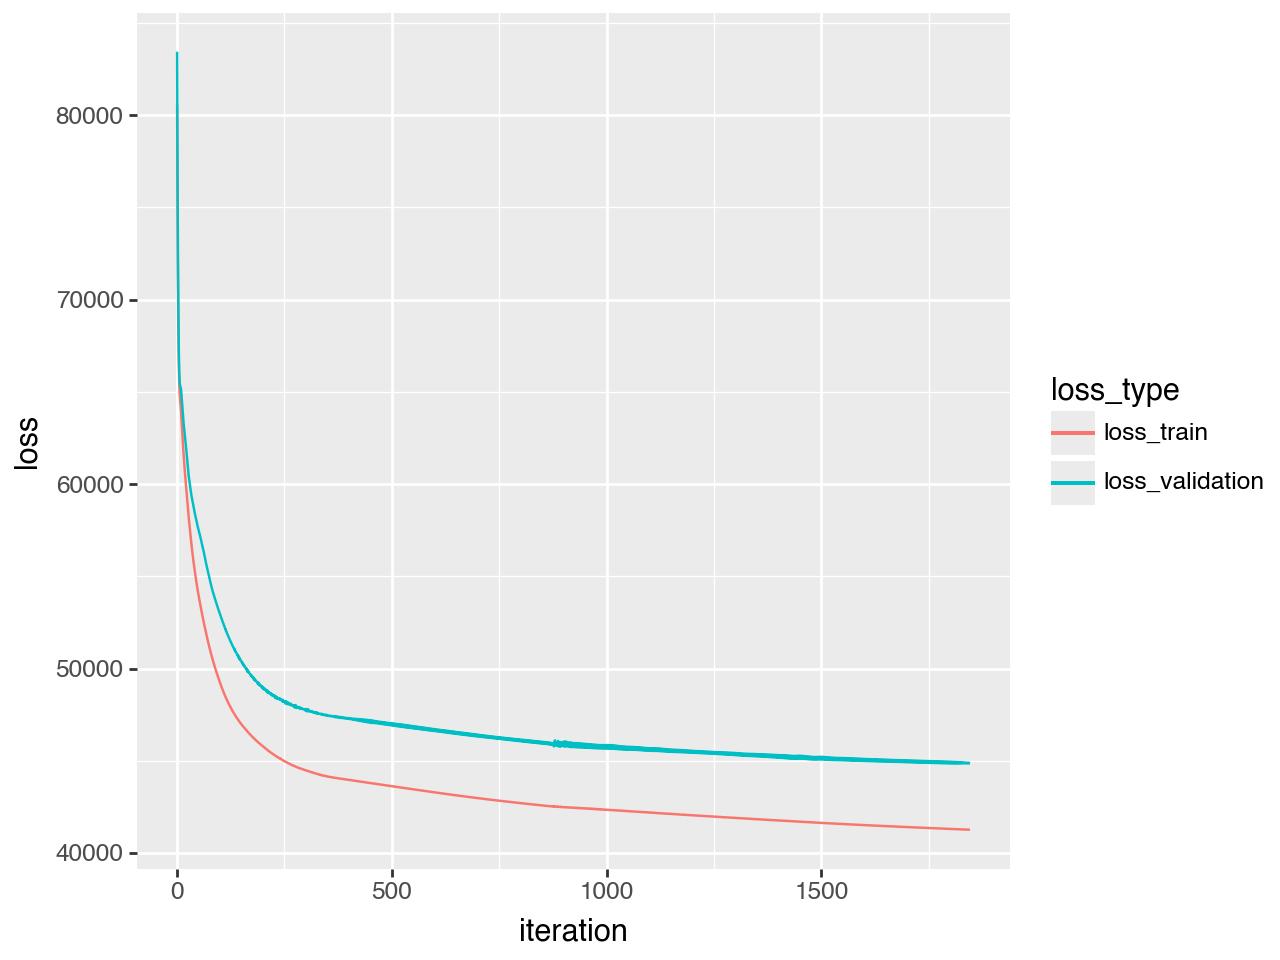

In [83]:
plot_loss(result)

## Dependence model (Scalable Bayesian transport map)

In [84]:
# ----------------------------------------------------------------------------------
# Dependence Model
# ----------------------------------------------------------------------------------
tloc = torch.tensor(np.asarray(locs_model, dtype=np.float64), dtype=torch.float64)

# Finding nearest neighbors using the `veccs` package.
# The computation time of the model scales as a function of the condition set
# size. We recommend restricting this to be no larger than 30 neighbors.
largest_conditioning_set = 30

nn, _ = veccs.preceding_neighbors(
    coordinates=np.asarray(locs_model, dtype=np.float64),
    sequence=np.arange(locs_model.shape[0]),
    num_neighbors=largest_conditioning_set,
)

tnn = torch.as_tensor(nn, dtype=torch.int64)

train_data = Data.new(tloc, torch.tensor(train_hg, dtype=torch.float64), tnn)
validate_data = Data.new(tloc, torch.tensor(validate_hg, dtype=torch.float64), tnn)

tm = SimpleTM(train_data, theta_init=None, linear=False, smooth=1.5, nug_mult=4.0)

tm.double()

stopper = EarlyStopper(patience=10, min_diff=0.3)
opt = torch.optim.Adam(tm.parameters(), lr=0.01)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, 3_000)

start = time.time()
res = tm.fit(
    num_iter=3_000,
    init_lr=0.01,
    test_data=validate_data,
    optimizer=opt,
    stopper=stopper,
    scheduler=sched,
)
end = time.time()

time_t = end - start

Train Loss: -19245.565, Test Loss: 158.027:   2%|▏         | 61/3000 [00:04<03:42, 13.18it/s] 


<Axes: xlabel='Iteration', ylabel='Train Loss'>

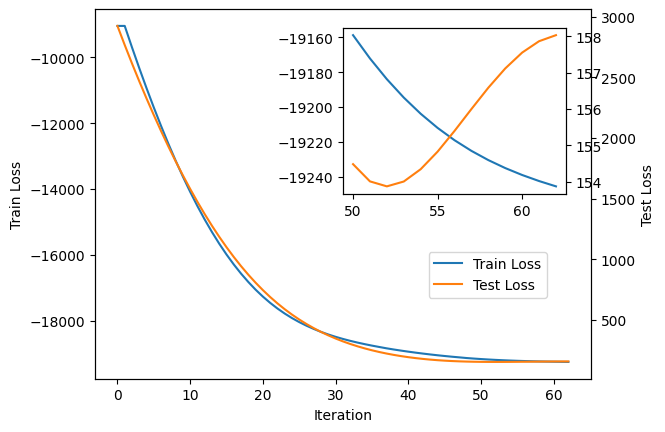

In [85]:
res.plot_loss()

## Evaluation

In [86]:
# the CompositeTransformations class provides functionality for coupling the
# marginal and the dependence model
sct = gptm.CompositeTransformations(marginal_model, tm)

### Log score computation

In [87]:
# ----------------------------------------------------------------------------------
# Log Scores
# ----------------------------------------------------------------------------------
log_score = sct.log_score(test, logdet_addition)

out = {
    "log_score": log_score,
    "time_hg": time_hg,
    "time_t": time_t,
}

### Drawing a new sample from the predictive distribution

In [88]:
y_new = sct.sample(key=jax.random.key(2), n=1)
y_new = y_new * train_sd + train_mean
sample_df = gptm.long_df(locs_2d, y_new)
sample_df

,loc,lon,lat,obs,value
0,0,272.50,4.240838,0,-16.194842
1,1,250.00,39.109948,0,-22.995467
2,2,250.00,-29.685864,0,-16.735643
3,3,295.00,-28.743455,0,-22.982222
4,4,295.00,34.397906,0,-17.822337
...,...,...,...,...,...
2733,2733,253.75,35.340314,0,-21.438073
2734,2734,292.50,35.340314,0,-16.780615
2735,2735,257.50,36.282723,0,-16.618855
2736,2736,280.00,36.282723,0,-15.621213


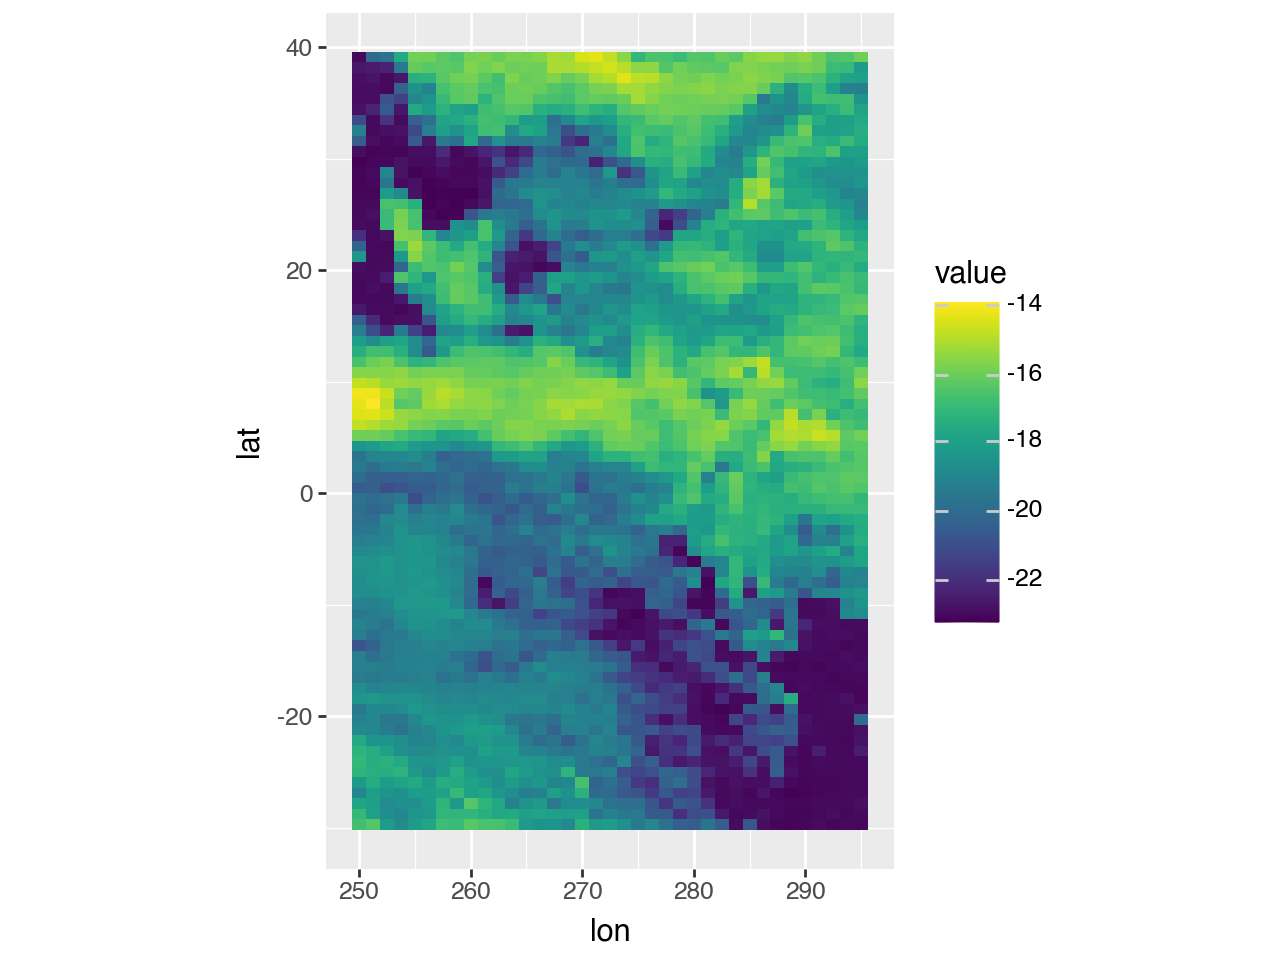

In [89]:
gptm.plot_df(sample_df)

### Drawing a conditional sample

Here, we fix the first 500 locations of a single holdout field and use our model to draw a new random sample, conditioning on these 500 fixed observations. This corresponds to the procedure in Figure 12 of Katzfuss & Schäfer (2023).

Katzfuss, M., & Schäfer, F. (2023). Scalable Bayesian transport maps for high-dimensional non-gaussian spatial fields. Journal of the American Statistical Association, 1–15. https://doi.org/10.1080/01621459.2023.2197158


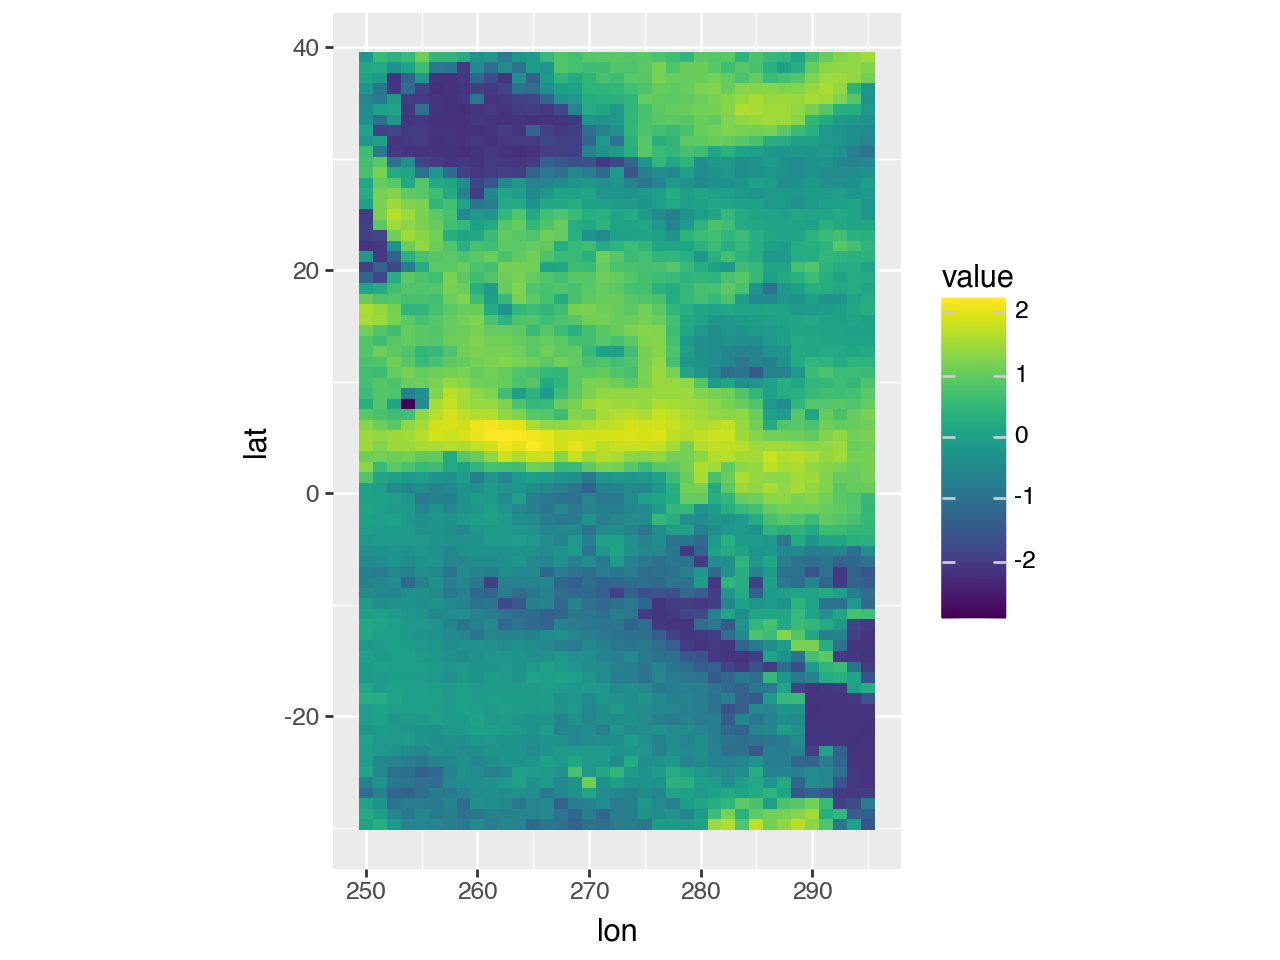

In [ ]:
fixy = test[1, :]

y_new = sct.sample(key=jax.random.key(2), n=1, fixed_y=fixy[:500])

cmin = min(fixy.min(), y_new.min())
cmax = min(fixy.max(), y_new.max())
sample_df = gptm.long_df(locs_2d, y_new)
gptm.plot_df(sample_df) + p9.scale_fill_cmap(limits=(cmin, cmax))

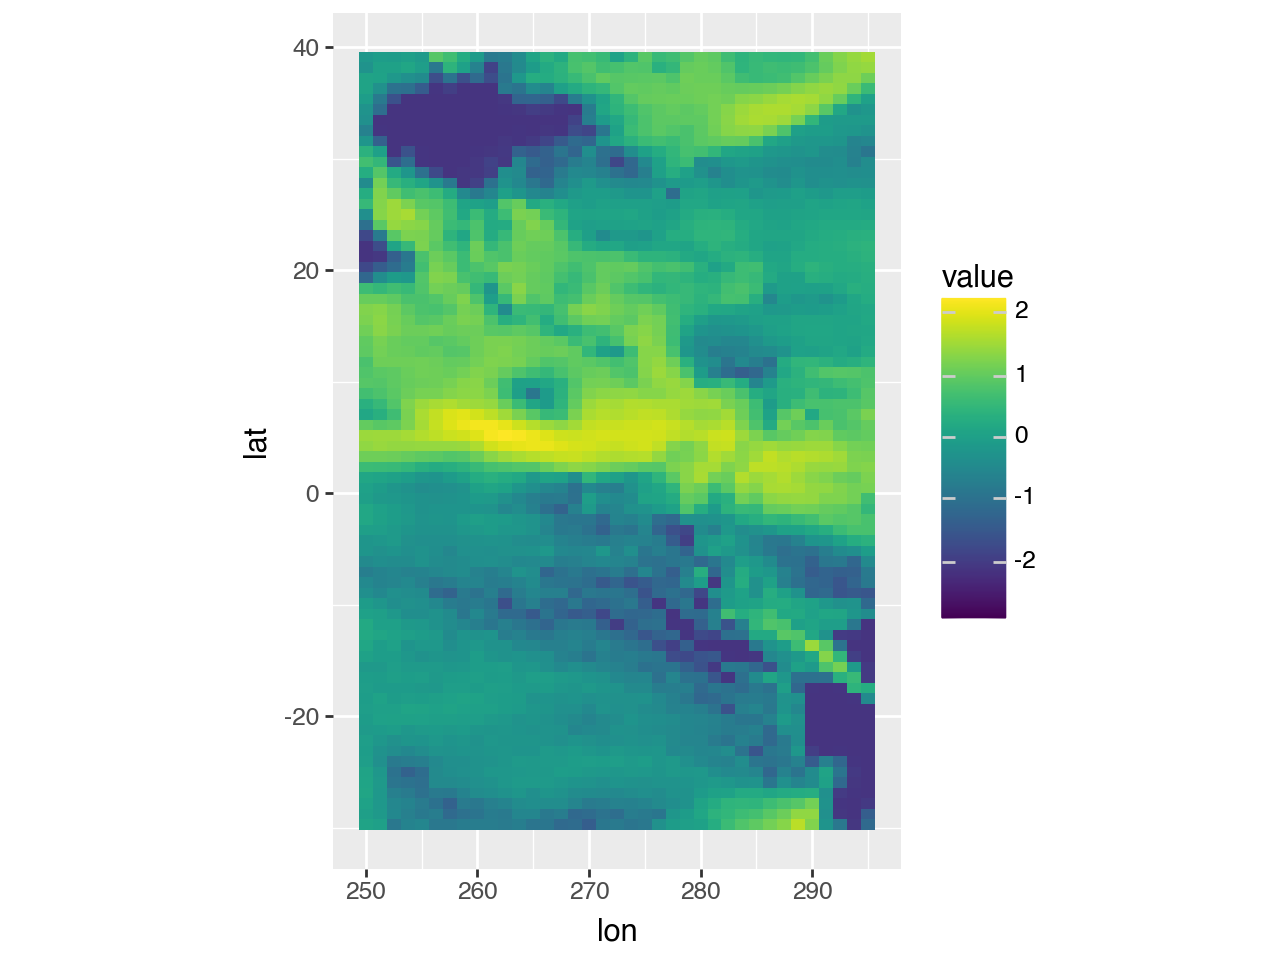

In [91]:
# the fixed field for comparison

sample_df = gptm.long_df(locs_2d, fixy)
gptm.plot_df(sample_df) + p9.scale_fill_cmap(limits=(cmin, cmax))